In [1]:
import os
import yaml
import random
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image

Load Dataset Config (data.yaml)

In [2]:
import os

print(os.getcwd())

c:\Users\94772\Desktop\swimming_pool_detection


In [3]:
import yaml

yaml_path = "dataset/data.yaml"

with open(yaml_path, "r", encoding="utf-8") as file:
    data = yaml.safe_load(file)

print(data["nc"])
print(data["names"])

6
['aluminium foil', 'ball', 'bottle', 'juice', 'leaf', 'thermocol']


In [4]:
print("Train path:", data["train"])
print("Validation path:", data["val"])
print("Test path:", data["test"])

Train path: ../train/images
Validation path: ../valid/images
Test path: ../test/images


Count Images in Dataset

In [5]:
def count_images(folder):
    return len(os.listdir(folder))

train_images = count_images("dataset/train/images")
val_images = count_images("dataset/valid/images")
test_images = count_images("dataset/test/images")

print("Train images:", train_images)
print("Validation images:", val_images)
print("Test images:", test_images)

Train images: 3027
Validation images: 154
Test images: 25


Class Distribution

In [6]:
label_path = "dataset/train/labels"

class_counts = Counter()

for file in os.listdir(label_path):
    if file.endswith(".txt"):
        with open(os.path.join(label_path, file), "r") as f:
            for line in f:
                class_id = int(line.split()[0])
                class_counts[class_id] += 1

# Convert to readable format
for class_id, count in class_counts.items():
    print(data["names"][class_id], ":", count)

thermocol : 534
bottle : 1644
ball : 309
juice : 1068
aluminium foil : 912
leaf : 1042


Visualize Class Distribution

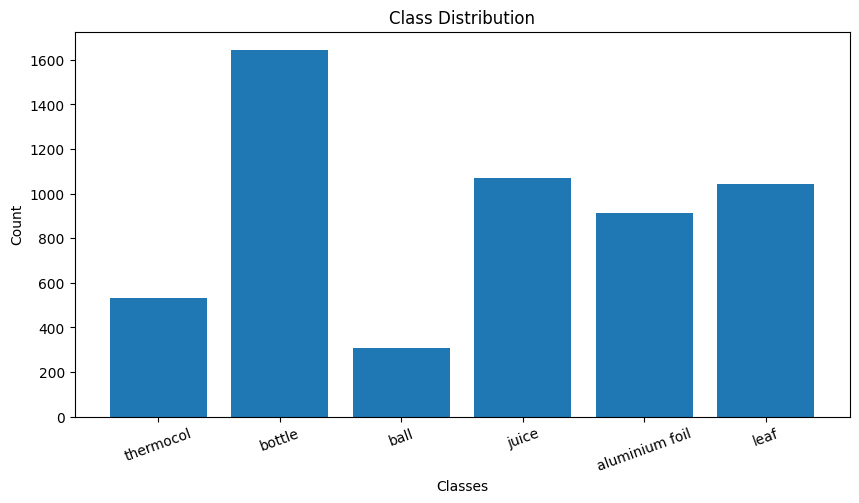

In [7]:
class_names = [data["names"][i] for i in class_counts.keys()]
counts = list(class_counts.values())

plt.figure(figsize=(10,5))
plt.bar(class_names, counts)
plt.xticks(rotation=20)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()

Check image size

In [8]:
image_folder = "dataset/train/images"

widths = []
heights = []

for img_name in os.listdir(image_folder):
    try:
        img = Image.open(os.path.join(image_folder, img_name))
        widths.append(img.width)
        heights.append(img.height)
    except:
        pass

print("Min Width:", min(widths))
print("Max Width:", max(widths))
print("Min Height:", min(heights))
print("Max Height:", max(heights))

Min Width: 640
Max Width: 640
Min Height: 640
Max Height: 640


Sample

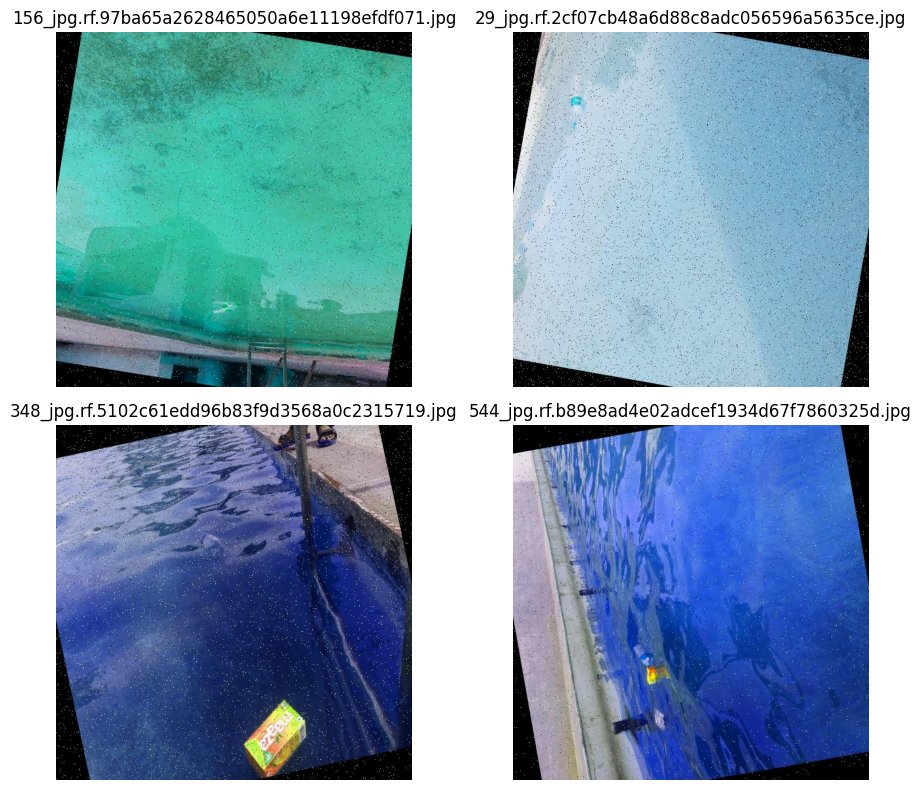

In [22]:
samples = random.sample(os.listdir(image_folder), 4)

plt.figure(figsize=(10,8))

for i, img_name in enumerate(samples):
    img = Image.open(os.path.join(image_folder, img_name))

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)

plt.tight_layout()
plt.show()

In [11]:
print("===== DATASET SUMMARY =====")
print("Classes:", data["names"])
print("Train images:", train_images)
print("Validation images:", val_images)
print("Test images:", test_images)
print("Total labeled objects:", sum(class_counts.values()))

===== DATASET SUMMARY =====
Classes: ['aluminium foil', 'ball', 'bottle', 'juice', 'leaf', 'thermocol']
Train images: 3027
Validation images: 154
Test images: 25
Total labeled objects: 5509
